In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error

In [4]:
train = pd.read_csv("../data/stock_5_train.csv")
test = pd.read_csv("../data/stock_5_test.csv")

print(f"Train: {train.shape[0]} rows, {train.shape[1]-1} features")
print(f"Test: {test.shape[0]} row")
train.head()

Train: 799 rows, 20 features
Test: 1 row


,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_11,col_12,col_13,col_14,col_15,col_16,col_17,col_18,col_19,target
0,-0.863876,1.384891,0.361688,1.410418,-0.060149,0.511535,0.300228,-0.624111,-0.144144,-0.113100,...,-0.178223,-0.450654,0.645839,0.114892,0.450583,-0.494119,1.075894,0.150254,0.132111,244.393249
1,-0.489180,-0.216597,0.382571,-1.485321,-1.258863,0.001296,1.198746,-0.025397,-0.791660,-1.235792,...,-0.444204,-0.688237,-0.280983,1.078822,0.532685,-0.325607,-1.636023,-0.417160,-0.141984,238.383656
2,0.999336,0.097413,0.795778,-0.447158,-0.049559,-0.115499,-0.836057,0.662082,0.650249,0.337953,...,0.241783,1.512476,0.652450,-0.642665,-0.664439,0.788920,-0.832239,0.072264,-0.127097,263.925573
3,0.240389,-1.285496,0.955999,-2.445466,-0.586253,0.022930,-0.789762,-0.451756,1.839376,2.522597,...,-0.877818,0.385110,-0.782441,-0.876537,-0.019090,-0.686826,-3.150789,0.264498,-0.643250,256.286502
4,-0.760509,-0.560754,-0.022248,-1.562884,0.228770,0.967466,0.292934,-1.588898,-0.123809,-0.243013,...,-0.118053,-1.542348,-2.174826,-0.366245,0.773324,-1.892774,-1.363660,1.797178,0.637749,249.007776


In [5]:
train.describe()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_11,col_12,col_13,col_14,col_15,col_16,col_17,col_18,col_19,target
count,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,...,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000
mean,-0.008699,0.013063,-0.021405,0.029708,-0.044226,0.023312,-0.021348,-0.054986,-0.021209,-0.006207,...,-0.037057,0.007411,0.002861,-0.025453,-0.013413,-0.061564,0.041955,0.054402,0.045061,253.136998
std,0.981782,1.020322,0.991761,1.004470,0.967300,1.007710,1.020018,1.017179,0.995124,1.119874,...,1.089603,1.078443,1.122999,1.111774,1.124437,1.073073,1.102386,1.100780,1.093748,30.787823
min,-2.745614,-3.082920,-2.762676,-3.016381,-2.985823,-3.017790,-3.073030,-4.389115,-3.263267,-3.984485,...,-3.825527,-2.838659,-4.743311,-3.322482,-3.404740,-5.126764,-3.636968,-3.278214,-3.078165,80.000000
25%,-0.628465,-0.724345,-0.672921,-0.645933,-0.672797,-0.638011,-0.713699,-0.723109,-0.724200,-0.750899,...,-0.758604,-0.746720,-0.750901,-0.751753,-0.773490,-0.798489,-0.677031,-0.677520,-0.675125,241.761369
50%,-0.010745,0.041724,0.011828,0.051823,-0.087959,0.046297,-0.042683,-0.059444,-0.029961,0.009910,...,-0.077916,0.034976,-0.014122,-0.029886,0.018915,-0.072275,0.088777,0.089999,0.056158,251.775856
75%,0.631945,0.749855,0.615189,0.706321,0.549201,0.705301,0.696910,0.574352,0.668709,0.690694,...,0.660121,0.748410,0.732324,0.754046,0.762993,0.685688,0.759496,0.795505,0.786125,263.898071
max,2.958335,3.454046,3.271026,3.179864,3.088512,3.064728,3.241259,3.435928,2.905067,3.277663,...,3.326665,3.352463,3.494917,3.732160,3.931799,3.595878,3.296926,3.167159,4.040122,400.000000


In [6]:
print(train.isnull().any().sum(), "null columns")
print(train.dtypes.value_counts())

0 null columns
float64    21
Name: count, dtype: int64


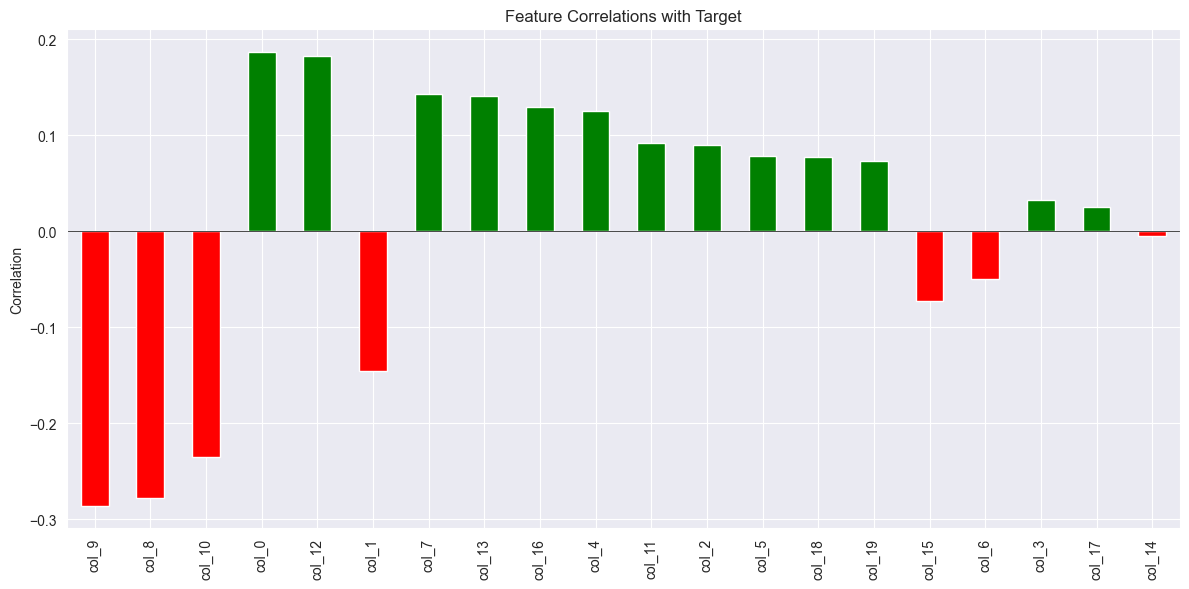

col_9    -0.285559
col_8    -0.278120
col_10   -0.234745
col_0     0.186483
col_12    0.182846
col_1    -0.145419
col_7     0.142948
col_13    0.141260
col_16    0.129776
col_4     0.125626
col_11    0.091962
col_2     0.090041
col_5     0.078611
col_18    0.077724
col_19    0.072727
col_15   -0.072477
col_6    -0.049622
col_3     0.032633
col_17    0.024874
col_14   -0.004645
Name: target, dtype: float64


In [7]:
corr = train.corr()['target'].drop('target').sort_values(key=abs, ascending=False)

plt.figure(figsize=(12, 6))
corr.plot(kind='bar', color=['red' if x < 0 else 'green' for x in corr])
plt.title('Feature Correlations with Target')
plt.ylabel('Correlation')
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print(corr)

In [8]:
X = train.drop('target', axis=1)
y = train['target']

lr_all = LinearRegression().fit(X, y)

print(f"R²: {lr_all.score(X, y):.6f}")
print(f"Intercept: {lr_all.intercept_:.4f}")
for col, coef in zip(X.columns, lr_all.coef_):
    print(f"  {col}: {coef:.4f}")

R²: 0.208987
Intercept: 253.3032
  col_0: 5.4856
  col_1: -3.9996
  col_2: 2.9955
  col_3: 1.1058
  col_4: 7.6620
  col_5: 0.8351
  col_6: -4.3865
  col_7: 3.8613
  col_8: -8.1349
  col_9: -2.8364
  col_10: 2.7791
  col_11: -2.9986
  col_12: 0.3575
  col_13: 1.6032
  col_14: 6.0337
  col_15: -3.4068
  col_16: -0.8022
  col_17: -0.2322
  col_18: 1.5833
  col_19: 0.1288


In [9]:
# Identify features by correlation strength
corrs = train.corr()['target'].drop('target')
strong = list(corrs[corrs.abs() > 0.1].index)
weak = list(corrs[corrs.abs() <= 0.1].index)

print(f"Strong features ({len(strong)}): {strong}")
print(f"Weak/noise features ({len(weak)}): {weak}")

# Compare models with 5-fold CV
from sklearn.model_selection import cross_val_score

models = {
    'Linear (all 20)': (LinearRegression(), train.drop('target', axis=1).columns.tolist()),
    'Linear (strong)': (LinearRegression(), strong),
    'Linear (top 3)': (LinearRegression(), ['col_9', 'col_8', 'col_10']),
    'Ridge a=1 (all)': (Ridge(alpha=1), train.drop('target', axis=1).columns.tolist()),
    'Ridge a=10 (all)': (Ridge(alpha=10), train.drop('target', axis=1).columns.tolist()),
    'Ridge a=100 (all)': (Ridge(alpha=100), train.drop('target', axis=1).columns.tolist()),
    'Ridge a=100 (strong)': (Ridge(alpha=100), strong),
}

print(f"\n{'Model':<25} {'CV RMSE':>10} {'Feats':>6}")
print("-" * 43)

for name, (model, cols) in models.items():
    X_m = train[cols]
    scores = cross_val_score(model, X_m, y, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    print(f"{name:<25} {rmse:>10.2f} {len(cols):>6}")

Strong features (10): ['col_0', 'col_1', 'col_4', 'col_7', 'col_8', 'col_9', 'col_10', 'col_12', 'col_13', 'col_16']
Weak/noise features (10): ['col_2', 'col_3', 'col_5', 'col_6', 'col_11', 'col_14', 'col_15', 'col_17', 'col_18', 'col_19']

Model                        CV RMSE  Feats
-------------------------------------------
Linear (all 20)                28.25     20
Linear (strong)                28.28     10
Linear (top 3)                 29.58      3
Ridge a=1 (all)                28.24     20
Ridge a=10 (all)               28.19     20
Ridge a=100 (all)              28.09     20
Ridge a=100 (strong)           28.24     10


In [10]:
X_all = train.drop('target', axis=1)
lr = LinearRegression().fit(X_all, y)
residuals = y - lr.predict(X_all)

print(f"Residual mean: {residuals.mean():.4f}")
print(f"Residual std: {residuals.std():.4f}")
print(f"Residual skew: {residuals.skew():.4f}")
print(f"Residual kurtosis: {residuals.kurtosis():.4f}")

# Check squared features (top 5 only)
print("\nCorrelation of residuals with squared features:")
for col in ['col_9', 'col_8', 'col_10', 'col_0', 'col_4']:
    corr_sq = np.corrcoef(residuals, train[col]**2)[0, 1]
    print(f"  resid vs {col}²: {corr_sq:.4f}")

# Check interactions between top features
print("\nCorrelation of residuals with interactions:")
top = ['col_9', 'col_8', 'col_10', 'col_0', 'col_4']
for i in range(len(top)):
    for j in range(i+1, len(top)):
        interaction = train[top[i]] * train[top[j]]
        corr = np.corrcoef(residuals, interaction)[0, 1]
        if abs(corr) > 0.05:
            print(f"  resid vs {top[i]}*{top[j]}: {corr:.4f}")

Residual mean: -0.0000
Residual std: 27.3824
Residual skew: -0.0461
Residual kurtosis: 10.8415

Correlation of residuals with squared features:
  resid vs col_9²: 0.0553
  resid vs col_8²: 0.0092
  resid vs col_10²: -0.0157
  resid vs col_0²: 0.1294
  resid vs col_4²: -0.0160

Correlation of residuals with interactions:


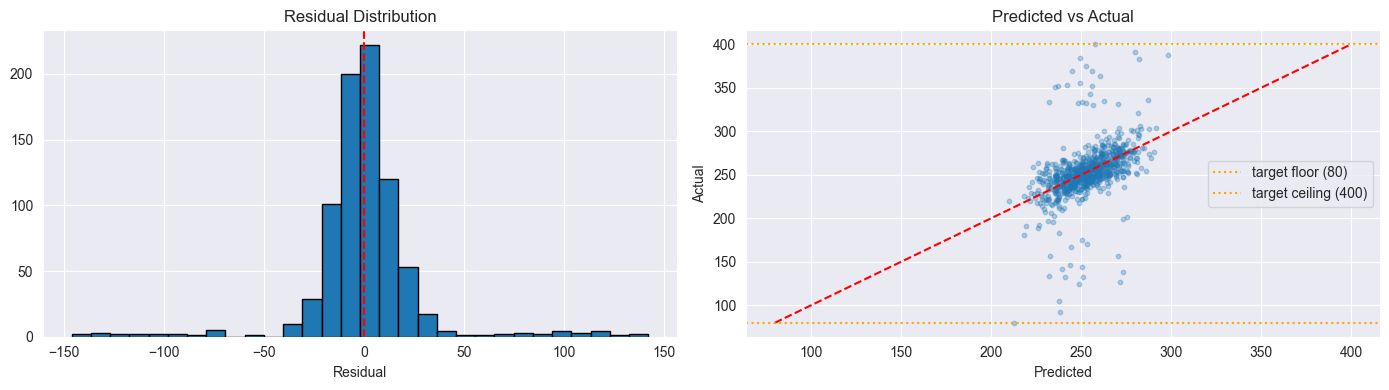

Targets at floor (80): 1
Targets at ceiling (400): 0


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(residuals, bins=30, edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual')

axes[1].scatter(lr.predict(X_all), y, alpha=0.3, s=10)
axes[1].plot([80, 400], [80, 400], 'r--')
axes[1].axhline(80, color='orange', linestyle=':', label='target floor (80)')
axes[1].axhline(400, color='orange', linestyle=':', label='target ceiling (400)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Predicted vs Actual')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Targets at floor (80): {(y == 80).sum()}")
print(f"Targets at ceiling (400): {(y == 400).sum()}")

In [12]:
# Difference features between top correlated features
top = ['col_9', 'col_8', 'col_10', 'col_0', 'col_4']

print("Difference feature correlations with target:")
for i in range(len(top)):
    for j in range(i+1, len(top)):
        diff = train[top[i]] - train[top[j]]
        corr = diff.corr(train['target'])
        if abs(corr) > 0.15:
            print(f"  {top[i]} - {top[j]}: {corr:.4f}")

# Transformation library
library = {
    'sq_col9': train['col_9']**2,
    'sq_col8': train['col_8']**2,
    'sq_col0': train['col_0']**2,
    'log_col9': np.log(np.abs(train['col_9']) + 1),
    'log_col8': np.log(np.abs(train['col_8']) + 1),
    'sin_col9': np.sin(train['col_9']),
    'sin_col8': np.sin(train['col_8']),
    'abs_col9': np.abs(train['col_9']),
    'abs_col8': np.abs(train['col_8']),
    'col9_cube': train['col_9']**3,
    'col8_cube': train['col_8']**3,
    'interact_8_9': train['col_8'] * train['col_9'],
    'interact_0_9': train['col_0'] * train['col_9'],
    'interact_0_8': train['col_0'] * train['col_8'],
}

print("\nTransformation correlations with residuals:")
print(f"{'Feature':<20} {'Corr':>8}")
print("-" * 30)

for name, feature in sorted(library.items(), key=lambda x: abs(np.corrcoef(x[1], residuals)[0,1]), reverse=True):
    corr = np.corrcoef(feature, residuals)[0, 1]
    marker = " ***" if abs(corr) > 0.1 else ""
    print(f"{name:<20} {corr:>8.4f}{marker}")

Difference feature correlations with target:
  col_9 - col_0: -0.3309
  col_9 - col_4: -0.2988
  col_8 - col_0: -0.3254
  col_8 - col_4: -0.2915
  col_10 - col_0: -0.2974
  col_10 - col_4: -0.2602

Transformation correlations with residuals:
Feature                  Corr
------------------------------
sq_col0                0.1294 ***
col8_cube             -0.0688
col9_cube             -0.0600
sq_col9                0.0553
sin_col8               0.0396
sin_col9               0.0395
interact_0_8           0.0369
interact_8_9           0.0362
abs_col9               0.0353
interact_0_9           0.0326
log_col9               0.0254
sq_col8                0.0092
log_col8              -0.0036
abs_col8              -0.0014


In [13]:
# Test if difference features or sq_col0 improve the model
X_base = train[['col_9', 'col_8', 'col_10', 'col_0', 'col_4', 'col_1', 'col_7', 'col_12', 'col_13', 'col_16']]

# Add difference features
X_diff = X_base.copy()
X_diff['col9_minus_col0'] = train['col_9'] - train['col_0']
X_diff['col8_minus_col0'] = train['col_8'] - train['col_0']

# Add sq_col0
X_sq = X_base.copy()
X_sq['sq_col0'] = train['col_0']**2

tests = {
    'Ridge100 (strong 10)': (Ridge(alpha=100), X_base),
    'Ridge100 (+ diffs)': (Ridge(alpha=100), X_diff),
    'Ridge100 (+ sq_col0)': (Ridge(alpha=100), X_sq),
    'Ridge100 (all 20)': (Ridge(alpha=100), train.drop('target', axis=1)),
}

print(f"{'Model':<30} {'CV RMSE':>10}")
print("-" * 42)

for name, (model, X_m) in tests.items():
    scores = cross_val_score(model, X_m, y, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    print(f"{name:<30} {rmse:>10.2f}")

Model                             CV RMSE
------------------------------------------
Ridge100 (strong 10)                28.24
Ridge100 (+ diffs)                  28.22
Ridge100 (+ sq_col0)                28.18
Ridge100 (all 20)                   28.09


In [14]:
model = Ridge(alpha=100)
X_all = train.drop('target', axis=1)
model.fit(X_all, y)

residuals = y - model.predict(X_all)
sigma = residuals.std()

print(f"Final model: Ridge(alpha=100) on all 20 features")
print(f"Train R²: {model.score(X_all, y):.4f}")
print(f"Noise σ (training): {sigma:.2f}")
print(f"CV RMSE (honest):   28.09")

test_pred = model.predict(test)[0]

print(f"\nPredicted target: {test_pred:.4f}")

honest_sigma = 28.09
print(f"\n1 SD range: [{test_pred - honest_sigma:.2f}, {test_pred + honest_sigma:.2f}]")
print(f"2 SD range: [{test_pred - 2*honest_sigma:.2f}, {test_pred + 2*honest_sigma:.2f}]")
print(f"3 SD range: [{test_pred - 3*honest_sigma:.2f}, {test_pred + 3*honest_sigma:.2f}]")

Final model: Ridge(alpha=100) on all 20 features
Train R²: 0.2017
Noise σ (training): 27.51
CV RMSE (honest):   28.09

Predicted target: 249.6788

1 SD range: [221.59, 277.77]
2 SD range: [193.50, 305.86]
3 SD range: [165.41, 333.95]
